# 03 — Clustering (K-Means)

**Input:** `data/processed/processed_data.csv`  
**Output:** `data/processed/clustered_data.csv`, `models/kmeans_model.pkl`

> See `rough.py` for scratch/experimental clustering code.


In [24]:
# Clustering code goes here

In [36]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pickle
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv('../data/processed/processed_data.csv')
print("processed data shape:", df.shape)

processed data shape: (8068, 9)


# Elbow Method

In [38]:
inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df)
    inertias.append(km.inertia_)

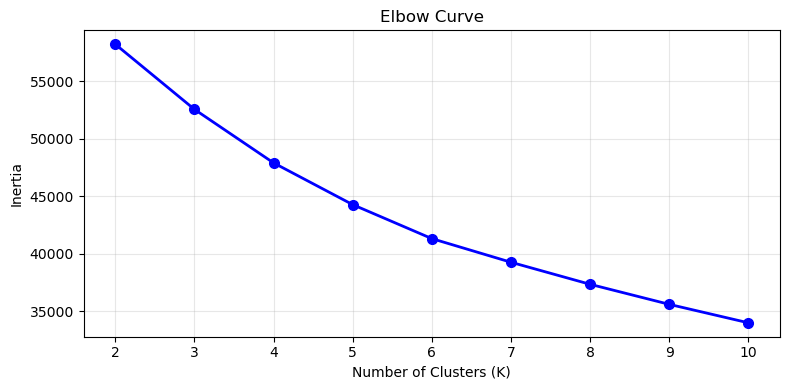

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/elbow_curve.png', dpi=150)
plt.show()

In [39]:
# From the elbow curve, we can see that the optimal number of clusters is around 4 or 5. Let's choose K=5 for our final model.
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df)

print('Cluster distribuition:')
print(pd.Series(clusters).value_counts().sort_index())

Cluster distribuition:
0    1628
1    1564
2     911
3    1725
4    2240
Name: count, dtype: int64


# PCA visualization

In [40]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(df)
pca_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

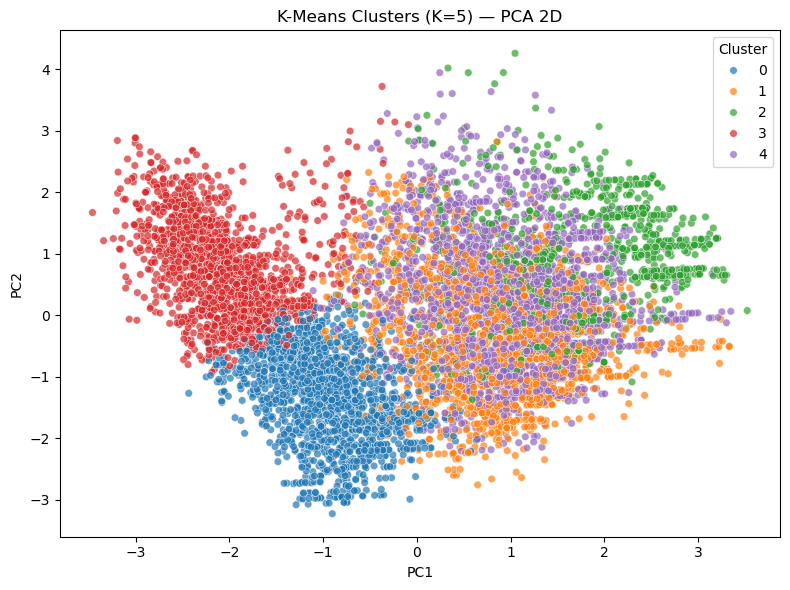

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7, s=30)
plt.title(f'K-Means Clusters (K={k_optimal}) — PCA 2D')
plt.tight_layout()
plt.savefig('../plots/cluster_scatter.png', dpi=150)
plt.show()

# save clustered data and model

In [43]:
raw = pd.read_csv('../data/raw/raw_data.csv')
raw['Cluster'] = clusters
raw.to_csv('../data/processed/clustered_data.csv', index=False)
print('Saved clustered_data.csv — shape:', raw.shape)

Saved clustered_data.csv — shape: (8068, 11)


In [44]:
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print('Saved kmeans_model.pkl')

Saved kmeans_model.pkl


In [45]:
# Cluster profiles
print('\nCluster Profiles:')
print(raw.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].mean().round(2))



Cluster Profiles:
           Age  Work_Experience  Family_Size
Cluster                                     
0        37.47             3.79         1.86
1        46.98             2.73         2.78
2        73.04             1.16         2.04
3        26.47             2.34         4.17
4        46.44             2.55         2.94
